In [1]:
import os
os.environ['JAX_ENABLE_X64'] = '1'
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.1' 

%matplotlib widget
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp

import numpy as np
from temgym_core.components import Detector
from temgym_core.gaussian import GaussianRayBeta
from temgym_core.gaussian_taylor import (
    FreeSpaceParaxial, 
    Biprism,
    Lens,
    run_to_end,
)
from temgym_core.utils import energy2wavelength
from temgym_core.evaluate import evaluate_gaussians_gpu_kernel_wrapper, evaluate_gaussians_for, evaluate_gaussians_jax_scan


In [2]:
jax.config.update("jax_enable_x64", True)
W = 100e-9

Nx = Ny = 512
dx = W/Nx
dy = W/Ny
input_grid = Detector(z=0.0, pixel_size=(dx, dy), shape=(Nx, Ny))
coords = input_grid.coords
X, Y = coords[:,0].reshape(input_grid.shape), coords[:,1].reshape(input_grid.shape)
x, y = X[0,:], Y[:,0]
input_extent = (x[0], x[-1], y[0], y[-1])

distance = 1e-3
output_grid = Detector(z=distance, pixel_size=(dx * 4, dy * 4), shape=(Nx, Ny))
X_out, Y_out = output_grid.coords[:,0].reshape(output_grid.shape), output_grid.coords[:,1].reshape(output_grid.shape)
x_out, y_out = X_out[0,:], Y_out[:,0]
output_extent = (x_out[0], x_out[-1], y_out[0], y_out[-1])

voltage = 100e3
wavelength = energy2wavelength(voltage)  # 200 keV

In [3]:

from temgym_core.gaussian import TaylorExpofAction

k0 = 2 * jnp.pi / wavelength
num_rays = 1

key1, key2 = jax.random.PRNGKey(0), jax.random.PRNGKey(1)
num_rays_sqrt = int(jnp.ceil(jnp.sqrt(num_rays)))

rx, ry = 0, 0
w0 = 1e-8 # Beam waist
q =  - 1j * (2.0 / (k0 * w0**2))
Q_inv = jnp.array([[q, 0.0], [0.0, q]])
Q_inv = jnp.tile(Q_inv, (num_rays, 1, 1))

aperture_area = (W)**2
scale_factor = aperture_area / (w0 ** 2 * num_rays * np.pi)
C0 = jnp.ones(num_rays) * (1.0 * scale_factor + 0.0j)
voltage = jnp.full((num_rays,), voltage)

S = TaylorExpofAction(
    const=jnp.zeros(num_rays, dtype=jnp.complex128),
    lin=jnp.zeros((num_rays, 2), dtype=jnp.complex128),
    quad=Q_inv,
)
rays_in = GaussianRayBeta(x=rx, 
                         y=ry, 
                         dx=jnp.zeros(num_rays), 
                         dy=jnp.zeros(num_rays), 
                         z=jnp.zeros(num_rays), 
                         pathlength=jnp.zeros(num_rays),
                         _one=jnp.ones(num_rays),
                         C=C0,
                         S=S,
                         voltage=voltage)


rays_in=rays_in.to_vector()

R = 1e-5
lens = Lens(focal_length=R, z=0.0)

rays_out = run_to_end(rays_in, [lens])

In [5]:
E_in = evaluate_gaussians_for(rays_out, input_grid)
E_gpu = evaluate_gaussians_gpu_kernel_wrapper(rays_out, input_grid)
E_scan = evaluate_gaussians_jax_scan(rays_out, input_grid)

assert jnp.allclose(E_in, E_gpu), "E_in and E_gpu are not the same"
assert jnp.allclose(E_in, E_scan), "E_in and E_scan are not the same"
assert jnp.allclose(E_gpu, E_scan), "E_gpu and E_scan are not the same"

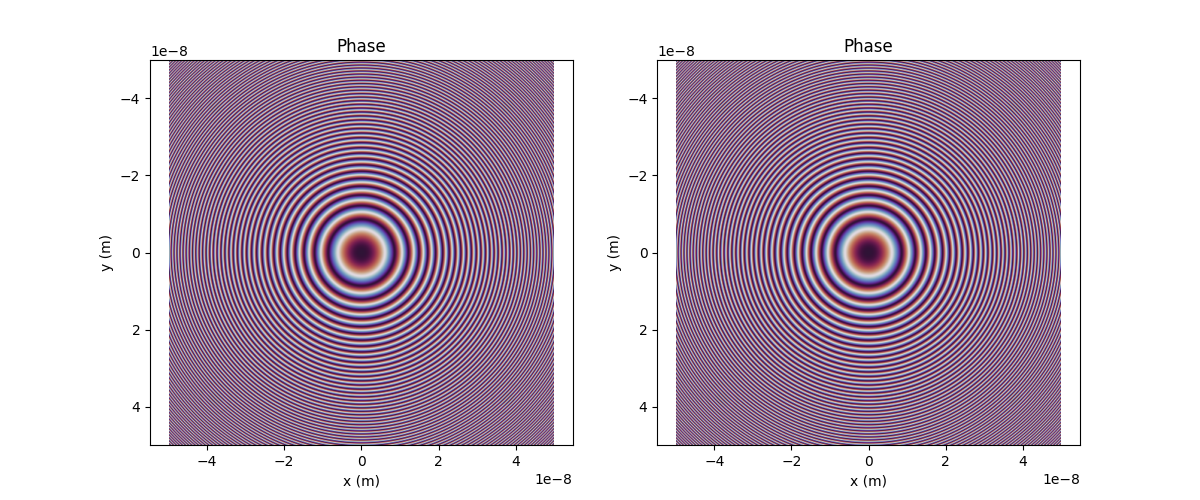

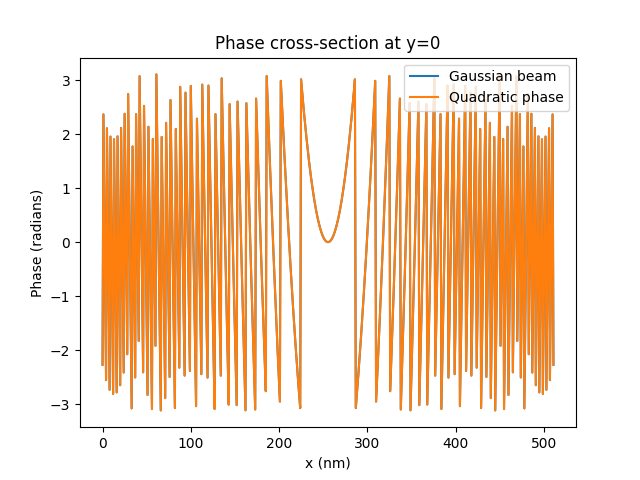

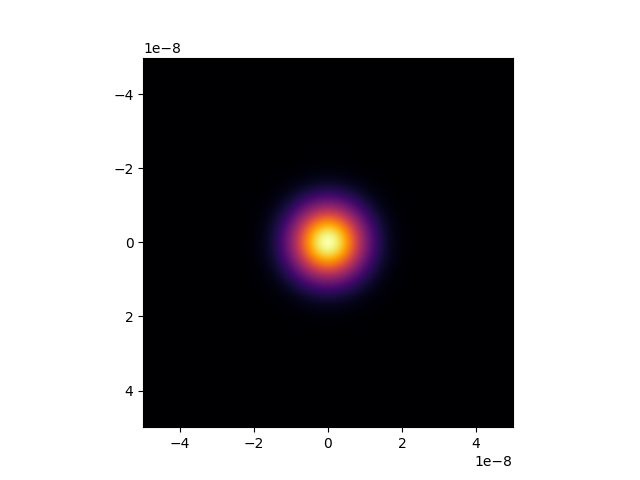

In [7]:
E_in = evaluate_gaussians_gpu_kernel_wrapper(rays_out, input_grid)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Phase of gaussian beam
axs[0].imshow(np.angle(E_in), extent=input_extent, cmap='twilight')
axs[0].set_title('Phase')
axs[0].set_xlabel('x (m)')
axs[0].set_ylabel('y (m)')
axs[0].axis('equal')

#  Quadratic phase factor for a lens
quadratic_phase = jnp.exp(1j * k0 / (2 * lens.focal_length) * (X**2 + Y**2))
axs[1].imshow(np.angle(quadratic_phase), extent=input_extent, cmap='twilight')
axs[1].set_title('Phase')
axs[1].set_xlabel('x (m)')
axs[1].set_ylabel('y (m)')
axs[1].axis('equal')

# Plot cross section
plt.figure()
plt.plot(np.angle(E_in[Nx//2,:]), label='Gaussian beam')
plt.plot(np.angle(quadratic_phase[Nx//2,:]), label='Quadratic phase')
plt.xlabel('x (nm)')
plt.ylabel('Phase (radians)')
plt.legend()
plt.title('Phase cross-section at y=0')

plt.figure()
plt.imshow(np.abs(E_in), extent=input_extent, cmap='inferno')
